In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
from sklearn.inspection import permutation_importance
from sksurv.metrics import concordance_index_censored
from sksurv.util import Surv

In [2]:
model = joblib.load('../app/data/hospital_closure_model.pkl')
test = pd.read_csv('../data/test_data_with_pred.csv')
train = pd.read_csv('../data/train_set.csv')
hospitals_full = pd.read_csv('../data/hospitals_full.csv')
hospitals_master = pd.read_csv('../data/hospitals_master.csv')
surv_functions = pd.read_csv('../data/surv_functions.csv')

In [3]:
test['CCN'] = test['CCN'].astype(int).astype(str).str.zfill(6)

In [4]:
hospitals_master['CCN'] = hospitals_master['CCN'].astype(str)
hospitals_master['CCN'] = hospitals_master['CCN'].str.zfill(6)

In [5]:
# Merge hospitals master with test data to bring back in identifying characteristics like hospital name
test_full = hospitals_master[['CCN','Facility Name','Prior Name','State','Closure Date']].merge(test, how='right', on='CCN')

In [6]:
test_full.head(2)

,CCN,Facility Name,Prior Name,State,Closure Date,NUMBER OF BEDS: Total Hospital,BALANCE SHEET: Total Current Assets (G_C1THRU4_11),Total Bad Debt expense,"RECONCILIATION OF CAPITAL COST CENTERS: Depreciation, Total (A7_3_C9_3)",BALANCE SHEET: Inventory (G_C1THRU4_7),...,"Hospital Type_Governmental, Federal",Hospital Type_Non-Profit,Hospital Type_Proprietary,"Hospital Type_Voluntary Nonprofit, Church","Hospital Type_Voluntary Nonprofit, Other","Hospital Type_Voluntary Nonprofit, Private",Pred_Closure,Status,Time,Year
0,190034,ABBEVILLE GENERAL HOSPITAL,NaN,LA,NaN,-0.942679,-0.343559,-0.609669,-0.693907,-0.474528,...,0.0,0.0,0.0,0.0,0.0,0.0,3.853884,False,15,2022
1,190034,ABBEVILLE GENERAL HOSPITAL,NaN,LA,NaN,-0.942679,-0.334018,-0.157608,-0.675230,-0.471774,...,0.0,0.0,0.0,0.0,0.0,0.0,3.570862,False,15,2023


Looking at survival function dataframe. Each value in the survival functions dataframe captures the probability that the given hospital will survive (remain open) beyond the year in the column.

In [7]:
surv_functions.columns = [2009 + int(float(col)) for col in surv_functions.columns]

In [8]:
surv_functions_full = pd.concat([test_full[['CCN','Facility Name','Year']], surv_functions], axis=1)
surv_functions_full.head(2)

,CCN,Facility Name,Year,2021,2023,2022
0,190034,ABBEVILLE GENERAL HOSPITAL,2022,0.956943,0.956943,0.956943
1,190034,ABBEVILLE GENERAL HOSPITAL,2023,0.967381,0.967381,0.967381


Extracting feature coefficients to see exactly how much each feature increases or decreases the log-hazard risk. A positive coefficient indicates a higher risk of hospital closure, while a negative coefficient indicates a protective effect.

In [9]:
feature_cols = [col for col in test.columns if col not in ('CCN','Pred_Closure','Status','Time','Year')]

feature_coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': model.coef_[:, 20] 
})

# Filter to see only the non-zero selected features
selected_features = feature_coef_df[feature_coef_df['Coefficient'] != 0]

In [10]:
pd.set_option('display.max_colwidth', None)
selected_features.sort_values(by='Coefficient').reset_index()

,index,Feature,Coefficient
0,70,Per Capita Hospital Admissions,-0.090763
1,74,"Per Capita Phys,Primary Care, Patient Care Non-Fed",-0.086665
2,75,Per Capita Short Term Gen Hosp Admissions,-0.084410
3,86,RUCA_1.0,-0.078098
4,68,Median Household Income,-0.069514
5,78,Per Capita Total Active M.D.s Non-Federal,-0.067521
6,79,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,-0.059686
7,73,Per Capita Personal Income,-0.044581
8,102,Metro_Status_Metropolitan Statistical Area,-0.027048
9,82,Population Estimate,-0.022475


In [55]:
selected_features[selected_features['Coefficient']>0].sort_values(by='Coefficient')

,Feature,Coefficient
80,Per Capita Total Number Hospitals,0.005955
69,Per Capita # Short Term General Hosps,0.056141
81,Percent Persons in Poverty,0.066226


Looking at the most impactful model features based on permutation importance scores. 

To evaluate the model performance, I'll use concordance_index_censored, which measures how accurately the model ranks hospitals by their risk of closure over time.

Permutation feature importance will measure how much the model's concordance_index_censored score drops when the values of a single feature are randomly shuffled.

In [11]:
feature_cols = [col for col in test.columns if col not in ('CCN','Status','Time','Pred_Closure','Year')]
X_test = test[feature_cols]
X_train = train[feature_cols]
y_test = test[['Status','Time']]

def c_index_scorer(model, X, y):
    predictions = model.predict(X)
    
    event_indicator = y_test['Status']
    event_time = y_test['Time']
    
    c_index, _, _, _, _ = concordance_index_censored(event_indicator, event_time, predictions)
    
    return c_index

# Permutation importance applied to the CoxnetSurvivalAnalysis model
feature_importances = permutation_importance(
    model, 
    X_test.to_numpy(), 
    Surv.from_arrays(y_test['Status'], y_test['Time']),
    random_state=0, 
    scoring=c_index_scorer,
    n_repeats=5 
)

# Create the results DataFrame
top_features_df = pd.DataFrame({
    'Feature': feature_cols,
    'Score': feature_importances['importances_mean']
}).sort_values('Score', ascending=False)

In [12]:
top_features_df.head()

,Feature,Score
86,RUCA_1.0,0.177387
102,Metro_Status_Metropolitan Statistical Area,0.026029
79,Per Capita Total Medicare Inpatient Days Short Term General Hospitals,0.008143
37,Financial Indicators: Net Profit Margin,0.007893
110,Hospital Type_Non-Profit,0.006829


In [13]:
top_features_df.sort_values('Score', ascending=True).head()

,Feature,Score
50,nsurveys,-0.004466
55,explain_score,-0.002187
57,info_score,-0.002003
62,understood_score,-0.001168
83,"Unemployment Rate, 16+",-0.001138


Investigating SHAP values. In this context, since we are using predict method as the scoring method, each SHAP value represents the amount a specific feature’s value pushes the risk score up or down relative to the baseline risk that a hospital will close.

In [14]:
# Sample the train data for faster runtime
X_train_summary = shap.sample(X_train.to_numpy(), nsamples=100)

# Pass the sampled train data to the explainer
explainer = shap.KernelExplainer(model.predict, X_train_summary)

# Compute SHAP values for test data
shap_values = explainer.shap_values(X_test.to_numpy())

  0%|          | 0/8410 [00:00<?, ?it/s]

In [15]:
exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test.values,
    feature_names=feature_cols
)

In [16]:
shap_df = pd.DataFrame(shap_values, columns=feature_cols)

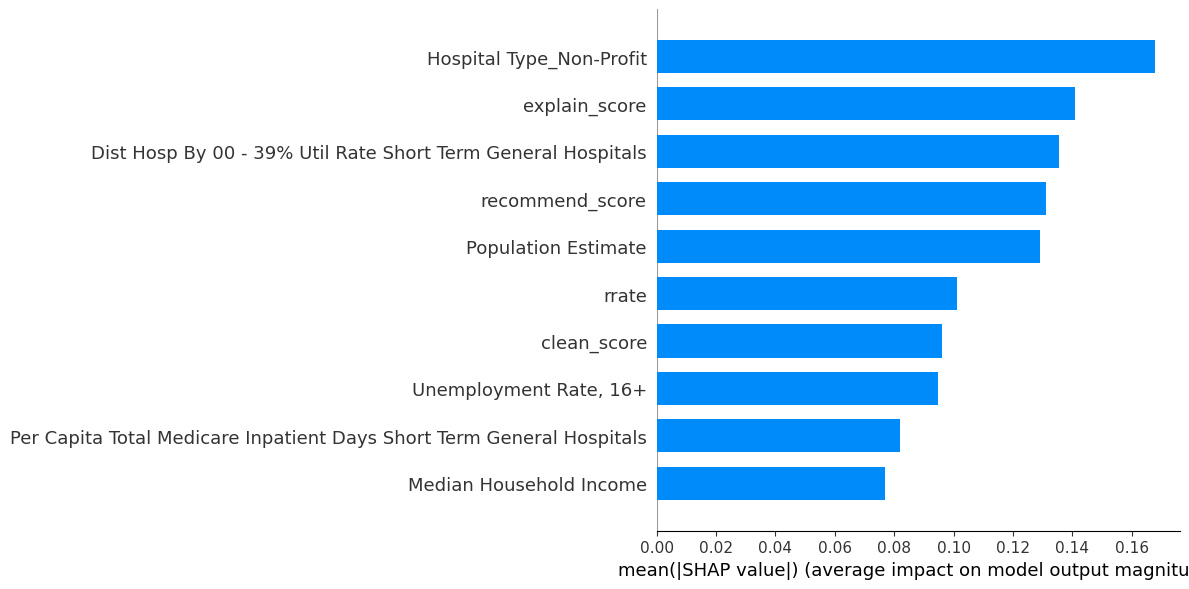

In [17]:
plt.figure(figsize=(12,6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False, plot_size=None)
plt.tight_layout()
plt.savefig("../app/images/shap_summary_bar_plot.png", bbox_inches="tight", dpi=300)

Case Studies:

Hospitals with the highest chance of closing, per our model:

In [18]:
test_full[['Facility Name','Pred_Closure','Year','Status','Time']].sort_values(by='Pred_Closure',ascending=False).head(5)

,Facility Name,Pred_Closure,Year,Status,Time
4611,MID COAST MEDICAL CENTER - TRINITY,6.903852,2023,False,15
4610,MID COAST MEDICAL CENTER - TRINITY,6.657481,2022,False,15
567,ASPIRUS ONTONAGON HOSPITAL,6.405961,2023,False,14
4058,MARTIN GENERAL HOSPITAL,6.323070,2023,True,13
1097,BLESSING HEALTH KEOKUK,5.097192,2022,True,12


Identifying good case studies based on facilities with the highest variance in their risk scores:

In [34]:
test_full.groupby(['CCN','Facility Name'])['Pred_Closure'].var().nlargest(5)

CCN     Facility Name                       
240006  OLMSTED MEDICAL CENTER                  34.323395
240010  MAYO CLINIC HOSPITAL ROCHESTER          33.698453
340061  UNC HOSPITALS                           11.948396
230046  UNIVERSITY OF MICHIGAN HEALTH SYSTEM     9.955233
230156  TRINITY HEALTH ANN ARBOR HOSPITAL        9.926029
Name: Pred_Closure, dtype: float64

#### SHAP plots:

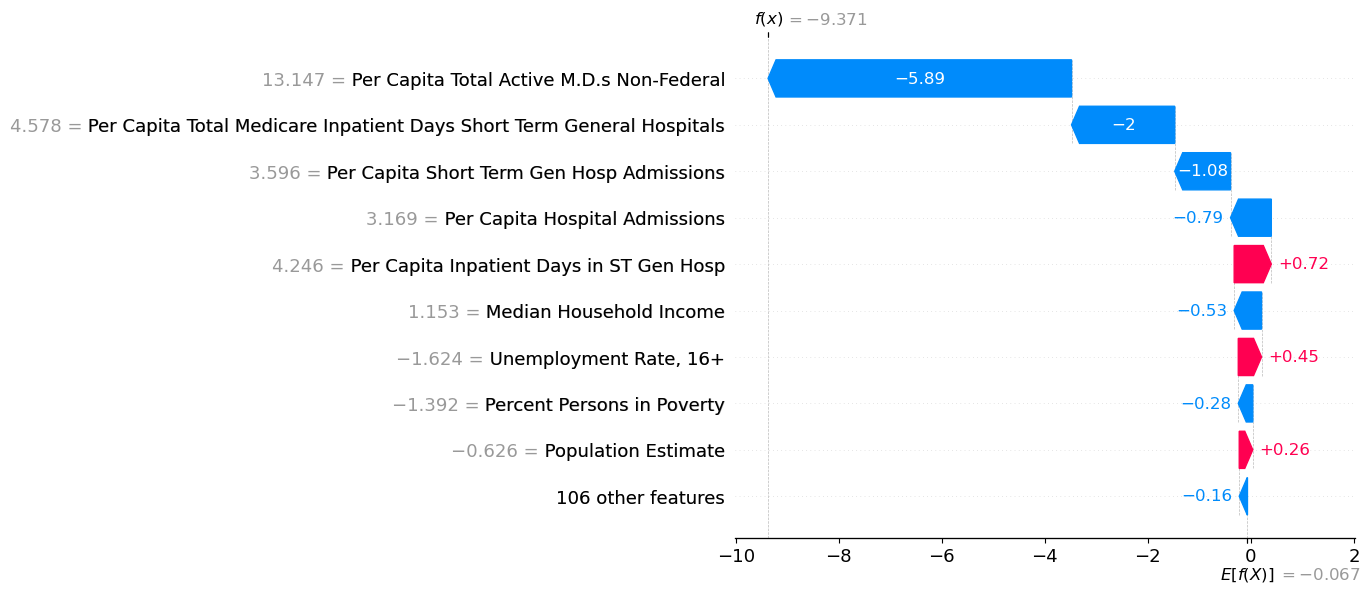

In [50]:
# OLMSTED MEDICAL CENTER in 2023
shap.plots.waterfall(exp[5295]) #show=False
#plt.savefig("../app/images/case_study.png", bbox_inches="tight", dpi=300)

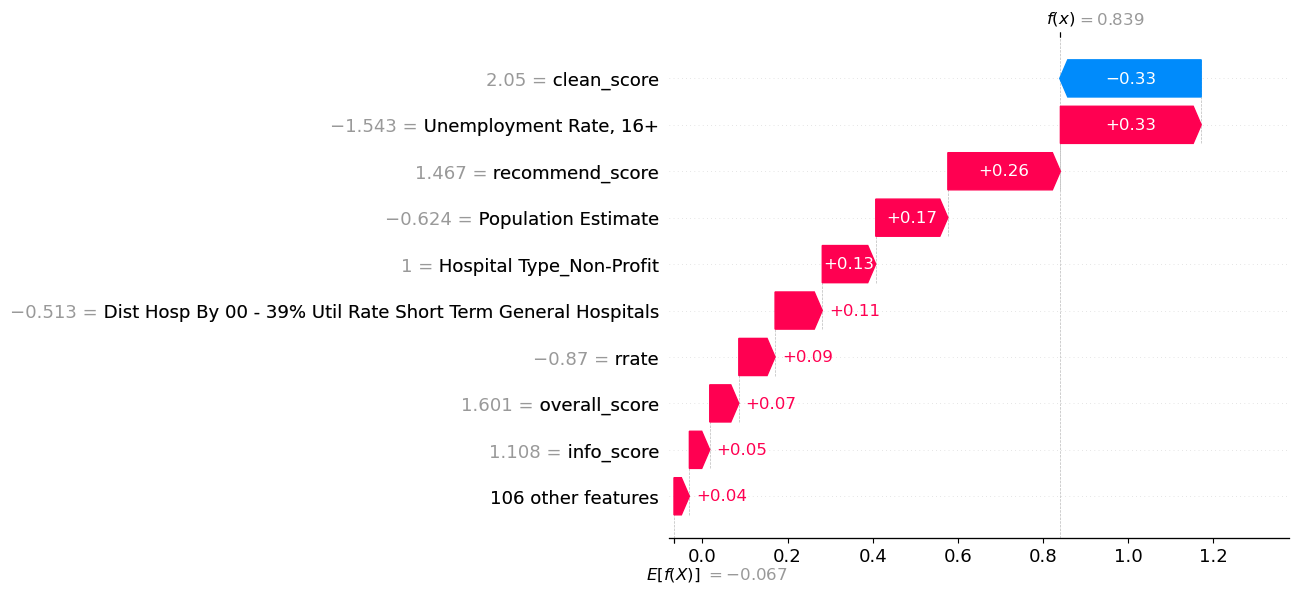

In [51]:
# OLMSTED MEDICAL CENTER in 2024
shap.plots.waterfall(exp[5296]) #show=False
#plt.savefig("../app/images/case_study.png", bbox_inches="tight", dpi=300)

In [49]:
test_full[test_full['Facility Name']=='OLMSTED MEDICAL CENTER']

,CCN,Facility Name,Prior Name,State,Closure Date,NUMBER OF BEDS: Total Hospital,BALANCE SHEET: Total Current Assets (G_C1THRU4_11),Total Bad Debt expense,"RECONCILIATION OF CAPITAL COST CENTERS: Depreciation, Total (A7_3_C9_3)",BALANCE SHEET: Inventory (G_C1THRU4_7),...,"Hospital Type_Governmental, Federal",Hospital Type_Non-Profit,Hospital Type_Proprietary,"Hospital Type_Voluntary Nonprofit, Church","Hospital Type_Voluntary Nonprofit, Other","Hospital Type_Voluntary Nonprofit, Private",Pred_Closure,Status,Time,Year
5294,240006,OLMSTED MEDICAL CENTER,NaN,MN,NaN,-0.851865,0.015431,-0.598573,-0.306448,-0.246577,...,0.0,1.0,0.0,0.0,0.0,0.0,-9.270295,False,15,2022
5295,240006,OLMSTED MEDICAL CENTER,NaN,MN,NaN,-0.851865,0.039853,-0.157608,-0.276429,-0.249212,...,0.0,1.0,0.0,0.0,0.0,0.0,-9.370713,False,15,2023
5296,240006,OLMSTED MEDICAL CENTER,NaN,MN,NaN,-0.851865,0.043811,-0.157608,-0.248085,-0.227075,...,0.0,1.0,0.0,0.0,0.0,0.0,0.839112,False,15,2024
5297,240006,OLMSTED MEDICAL CENTER,NaN,MN,NaN,-0.098642,-0.170732,-0.157608,-0.154560,-0.098261,...,0.0,1.0,0.0,0.0,0.0,0.0,0.814197,False,15,2025


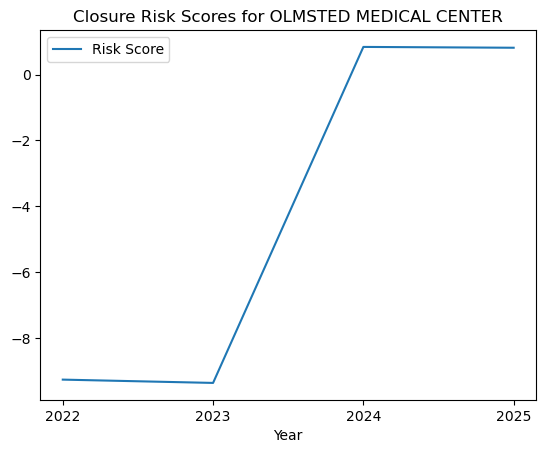

In [52]:
test_full[test_full['Facility Name']=='OLMSTED MEDICAL CENTER'].plot(kind='line',x='Year',y='Pred_Closure')
plt.title('Closure Risk Scores for OLMSTED MEDICAL CENTER')
plt.xticks([2022, 2023, 2024, 2025])
plt.legend(['Risk Score'])
#plt.savefig("../app/images/covenant_scores.png", bbox_inches="tight", dpi=300)
plt.show()